In [1]:
import h5py
from scipy.io import whosmat, loadmat
import numpy as np
import pickle
from himalaya.ridge import RidgeCV


In [2]:
base_path = "/srv/nfs-data/sisko/storage/fMRI_maas_2023"
math_path = base_path + "/Beta2hem.mat"

In [3]:
info = whosmat(math_path)

for name, shape, dtype in info:
    print(f"Variabile: {name}, shape: {shape}, tipo: {dtype}")

Variabile: BetasSEPTest, shape: (72, 1667), tipo: double
Variabile: BetasSEPTrain, shape: (216, 1667), tipo: double
Variabile: CV, shape: (1, 1), tipo: struct
Variabile: HG2hem, shape: (1, 1), tipo: struct
Variabile: InfoVTCTrain, shape: (1, 1), tipo: struct
Variabile: PP2hem, shape: (1, 1), tipo: struct
Variabile: PT2hem, shape: (1, 1), tipo: struct
Variabile: aSTG2hem, shape: (1, 1), tipo: struct
Variabile: cv, shape: (1, 1), tipo: double
Variabile: fmridirdata, shape: (1,), tipo: char
Variabile: mSTG2hem, shape: (1, 1), tipo: struct
Variabile: noCV, shape: (1, 1), tipo: double
Variabile: pSTG2hem, shape: (1, 1), tipo: struct
Variabile: reg, shape: (1, 1), tipo: double
Variabile: region, shape: (1, 1), tipo: struct
Variabile: regions_list, shape: (1, 6), tipo: cell
Variabile: s, shape: (1, 1), tipo: double
Variabile: sub, shape: (1, 1), tipo: double
Variabile: subject, shape: (1, 1), tipo: struct
Variabile: subjects_list, shape: (1, 5), tipo: cell
Variabile: testSounds, shape: (1, 72

In [4]:
def matlab_to_python(obj):
    """
    Converte ricorsivamente gli oggetti MATLAB letti da loadmat
    in strutture Python più leggibili:
    - struct MATLAB -> dict
    - cell array -> list
    - ndarray numerici -> ndarray
    - stringhe/scalari -> valori Python
    """
    # Struct MATLAB
    if hasattr(obj, "_fieldnames"):
        return {field: matlab_to_python(getattr(obj, field)) for field in obj._fieldnames}

    # Array numpy
    elif isinstance(obj, np.ndarray):
        # Array vuoto
        if obj.size == 0:
            return obj

        # Cell array o object array -> prova a convertirlo in lista
        if obj.dtype == object:
            if obj.ndim == 0:
                return matlab_to_python(obj.item())
            return [matlab_to_python(x) for x in obj.flat]

        # Array con un solo elemento -> scalar Python se possibile
        if obj.size == 1:
            try:
                return obj.item()
            except Exception:
                return obj

        return obj

    # Altri tipi: lascia così
    else:
        return obj

In [5]:
# Caricamento e conversione
raw_data = loadmat(math_path, struct_as_record=False, squeeze_me=True)
raw_data = {k: v for k, v in raw_data.items() if not k.startswith("__")}
data = {k: matlab_to_python(v) for k, v in raw_data.items()}

In [89]:
data["BetasSEPTrain"], data["BetasSEPTrain"].shape

(array([[ 1.4633024 ,  1.10715161,  1.57136241, ..., -0.12419284,
          0.0512253 ,  0.06037326],
        [ 1.58216144,  0.44355982,  1.62376205, ...,  0.16547049,
         -0.06590446,  0.08509112],
        [ 1.75557749,  1.13421204,  1.57125996, ...,  0.22550674,
         -0.02461643,  0.01483191],
        ...,
        [ 0.74571096,  0.72509141,  0.79952726, ..., -0.02687553,
          0.09386834, -0.08613259],
        [-0.33454996,  0.30133848, -0.0746192 , ...,  0.08894565,
         -0.16257438,  0.13024702],
        [-0.01495296,  0.27152439,  0.30373166, ..., -0.11780104,
          0.24168938,  0.19012366]]),
 (216, 1667))

In [88]:
data["InfoVTCTrain"], data["InfoVTCTrain"]["voxVTC"].shape

({'voxVTC': array([ 368260,  389141,  368261, ..., 2541354, 2458003, 2625212],
        dtype=int32),
  'Resolution': 1,
  'DimVTC': array([174, 120, 138], dtype=uint8)},
 (1667,))

In [6]:
# Liste di ROI e soggetti
roi_list = data["regions_list"]
subject_list = data["subjects_list"]
cv_list = ["CV1", "CV2", "CV3", "CV4"]

# Dizionario finale
data_by_subject = {}

for subj in subject_list:
    data_by_subject[subj] = {}

    for roi in roi_list:
        data_by_subject[subj][roi] = {}

        roi_struct = data[roi]   # es. data["HG2hem"]

        for cv in cv_list:
            if cv not in roi_struct:
                continue
            if subj not in roi_struct[cv]:
                continue

            subj_data = roi_struct[cv][subj]

            X_train = subj_data.get("BetasTrain", None)
            X_test = subj_data.get("BetasTest", None)
            train_sounds = subj_data.get("trainSounds", None)
            test_sounds = subj_data.get("testSounds", None)
            info_vtc = subj_data.get("InfoVTC", None)

            data_by_subject[subj][roi][cv] = {
                "X_train": X_train,
                "X_test": X_test,
                "train_sounds": train_sounds,
                "test_sounds": test_sounds,
                "info_vtc": info_vtc,
            }

print("Estrazione completata.")

Estrazione completata.


In [7]:
print(subject_list)
print(roi_list)

['KV', 'RS', 'RS1', 'RS2', 'RS3']
['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']


In [ ]:
subj = "KV"
roi = "pSTG2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

In [871]:
subj = "RS3"
roi = "PT2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry.keys())
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

dict_keys(['X_train', 'X_test', 'train_sounds', 'test_sounds', 'info_vtc'])
[ 261270  282149  282150 ... 2224707 2224360 2537564]
[174 120 138]
Subject: RS3
ROI: PT2hem
CV: CV2
X_train shape: (216, 4517)
X_test shape: (72, 4517)
train_sounds shape: (216,)
test_sounds shape: (72,)
train_sounds preview: [ 4  5  6  7  8  9 10 13 14 15]
test_sounds preview: [ 1  2  3 11 12 23 25 27 28 36]


In [872]:
entry["test_sounds"]

array([  1,   2,   3,  11,  12,  23,  25,  27,  28,  36,  38,  46,  51,
        55,  58,  60,  71,  73,  76,  77,  80,  85,  87,  88, 103, 104,
       105, 115, 118, 120, 126, 128, 129, 131, 132, 136, 163, 164, 165,
       166, 169, 174, 175, 176, 179, 181, 191, 192, 193, 195, 200, 201,
       205, 214, 221, 225, 229, 230, 231, 235, 241, 242, 246, 252, 256,
       258, 264, 266, 267, 268, 275, 282], dtype=uint16)

In [873]:
import re

def soundname_to_wav(sound_name: str) -> str:
    """
    Converte una stringa tipo:
    'stim145_cat04_music_exemp01'
    in:
    's2_music_1.wav'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)", sound_name)
    if m is None:
        raise ValueError(f"Formato inatteso: {sound_name}")

    category = m.group(1).lower()
    exemp = int(m.group(2))

    return f"s2_{category}_{exemp}.wav"

In [874]:
idx_train = entry["train_sounds"].astype(int) - 1
idx_test  = entry["test_sounds"].astype(int) - 1

In [875]:
import os
import numpy as np

wav_dir = "/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav"

name_sounds = np.load("/home/matteoc/brainSounds/maas_data/SoundNames.npy")

train_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_train
]

test_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_test
]

In [876]:
test_wav_paths

['/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_1.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_2.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_3.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_11.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_12.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_23.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_25.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_27.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_28.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_36.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_38.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_speech_46.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_voice_3.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_voice_7.wav',
 '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav/s2_voi

In [877]:
name_sounds

array(['stim001_cat01_speech_exemp01', 'stim002_cat01_speech_exemp02',
       'stim003_cat01_speech_exemp03', 'stim004_cat01_speech_exemp04',
       'stim005_cat01_speech_exemp05', 'stim006_cat01_speech_exemp06',
       'stim007_cat01_speech_exemp07', 'stim008_cat01_speech_exemp08',
       'stim009_cat01_speech_exemp09', 'stim010_cat01_speech_exemp10',
       'stim011_cat01_speech_exemp11', 'stim012_cat01_speech_exemp12',
       'stim013_cat01_speech_exemp13', 'stim014_cat01_speech_exemp14',
       'stim015_cat01_speech_exemp15', 'stim016_cat01_speech_exemp16',
       'stim017_cat01_speech_exemp17', 'stim018_cat01_speech_exemp18',
       'stim019_cat01_speech_exemp19', 'stim020_cat01_speech_exemp20',
       'stim021_cat01_speech_exemp21', 'stim022_cat01_speech_exemp22',
       'stim023_cat01_speech_exemp23', 'stim024_cat01_speech_exemp24',
       'stim025_cat01_speech_exemp25', 'stim026_cat01_speech_exemp26',
       'stim027_cat01_speech_exemp27', 'stim028_cat01_speech_exemp28',
      

## Audio Feature

In [878]:
import os
from pathlib import Path
import tqdm
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor


def load_clap_model(
    model_name: str = "laion/larger_clap_music_and_speech",
    device: str | None = None,
):
    """
    Carica modello e processor CLAP.
    get_audio_features(...) restituisce direttamente l'embedding proiettato.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    processor = ClapProcessor.from_pretrained(model_name)
    model = ClapModel.from_pretrained(model_name).to(device)
    model.eval()

    return model, processor, device


def load_audio_mono_resampled(wav_path: str, target_sr: int):
    """
    Carica un wav, lo converte in mono e lo resampla a target_sr.
    Restituisce un numpy array 1D.
    """
    audio, sr = torchaudio.load(wav_path)  # [channels, time]

    # mono
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    # resample
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        audio = resampler(audio)

    return audio.squeeze(0).numpy()


@torch.no_grad()
def extract_clap_projected_embeddings(
    wav_paths,
    model,
    processor,
    device,
    batch_size: int = 8,
):
    """
    Estrae embedding CLAP audio proiettati in 512 dimensioni.

    Args:
        wav_paths: lista di path wav
        model: ClapModel
        processor: ClapProcessor
        device: 'cuda' o 'cpu'
        batch_size: batch size per inference

    Returns:
        embeddings: torch.Tensor [N, 512]
    """
    all_embeddings = []

    # sampling rate attesa dal processor / feature extractor
    target_sr = processor.feature_extractor.sampling_rate

    for start in tqdm.tqdm(range(0, len(wav_paths), batch_size)):
        batch_paths = wav_paths[start:start + batch_size]

        audios = []
        for wav_path in batch_paths:
            audio_np = load_audio_mono_resampled(wav_path, target_sr=target_sr)
            audios.append(audio_np)

        inputs = processor(
            audios=audios,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        audio_embeds = model.get_audio_features(**inputs)

        all_embeddings.append(audio_embeds.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    return embeddings

In [879]:
import torch.nn.functional as F

model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

test_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=test_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=train_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = F.normalize(train_audio_embeds, dim=1).cpu().numpy()
test_audio_embeds  = F.normalize(test_audio_embeds, dim=1).cpu().numpy()

print(train_audio_embeds.shape) 
print(test_audio_embeds.shape) 

100%|██████████| 27/27 [00:03<00:00,  7.08it/s]

(216, 512)
(72, 512)


## Model

In [880]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from himalaya.ridge import RidgeCV
from sklearn.linear_model import Ridge
import torch
import numpy as np

train_mean_fmri = entry["X_train"].mean(axis=0, keepdims=True)
train_std_fmri  = entry["X_train"].std(axis=0, keepdims=True)

X_train = (entry["X_train"] - train_mean_fmri) / train_std_fmri
X_test  = (entry["X_test"]  - train_mean_fmri) / train_std_fmri

Y_train = train_audio_embeds
Y_test = test_audio_embeds

# alphas = np.logspace(-2,6,20)
alphas = [0.1,1,10,20,100,1000]

pipeline = Pipeline([
    ("ridge", RidgeCV(alphas=alphas))
])

pipeline.fit(X_train, Y_train)
voxels_scores=pipeline.score(X_train, Y_train)

test_audio_pred = pipeline.predict(X_test)

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/himalaya/ridge/_random_search.py:491: UserWarning: Solving ridge is slower than solving kernel ridge when n_samples < n_features (here 216 < 4517). Using a linear kernel in himalaya.kernel_ridge.KernelRidgeCV or himalaya.kernel_ridge.solve_kernel_ridge_cv_eigenvalues would be faster. Use warn=False to silence this warning.
  warnings.warn(


Mean cosine similarity: 0.26619303647247733
Median cosine similarity: 0.2661018610022976


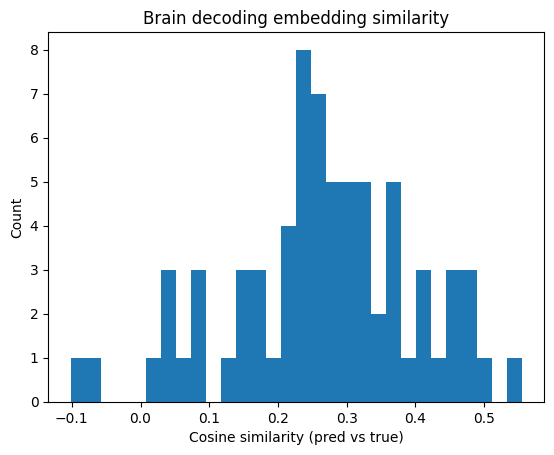

In [881]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sim = np.diag(cosine_similarity(test_audio_pred, Y_test))

print("Mean cosine similarity:", sim.mean())
print("Median cosine similarity:", np.median(sim))

plt.hist(sim, bins=30)
plt.xlabel("Cosine similarity (pred vs true)")
plt.ylabel("Count")
plt.title("Brain decoding embedding similarity")
plt.show()

In [882]:
random_idx = np.random.permutation(len(Y_test))

random_sim = np.diag(
    cosine_similarity(test_audio_pred, Y_test[random_idx])
)

print("True mean similarity:", sim.mean())
print("Random mean similarity:", random_sim.mean())

True mean similarity: 0.26619303647247733
Random mean similarity: -0.0001491374645575373


In [883]:
from sklearn.neighbors import NearestNeighbors

Y_test_norm = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)
test_audio_pred = test_audio_pred / np.linalg.norm(test_audio_pred, axis=1, keepdims=True)

nbrs = NearestNeighbors(n_neighbors=5, metric="cosine").fit(Y_test_norm)
distances, top_indices = nbrs.kneighbors(test_audio_pred)

top1 = np.mean(top_indices[:, 0] == np.arange(len(top_indices)))
top5 = np.mean([i in top_indices[i] for i in range(len(top_indices))])

print("Top-1:", top1)
print("Top-5:", top5)

Top-1: 0.20833333333333334
Top-5: 0.4583333333333333


Text(0.5, 1.0, 'Predicted vs True embeddings')

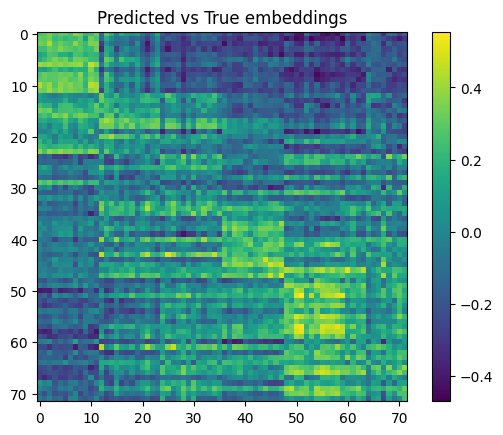

In [884]:
plt.imshow(cosine_similarity(test_audio_pred, Y_test))
plt.colorbar()
plt.title("Predicted vs True embeddings")